In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

# Data Preprocessing: Normalize pixel values
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0

# Split the full training data into validation and training sets
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

# Class names to use later for plotting and results
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# Print the data shapes to ensure everything is correct
print(f"Training data shape: {X_train.shape}")
print(f"Validation data shape: {X_valid.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (55000, 28, 28)
Validation data shape: (5000, 28, 28)
Testing data shape: (10000, 28, 28)


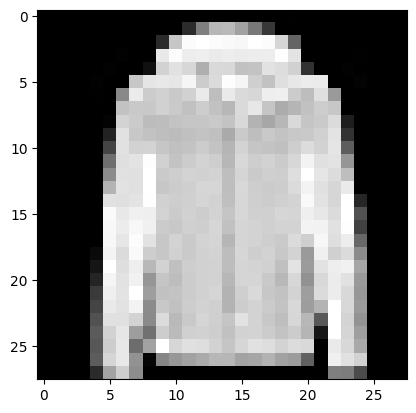

In [ ]:
plt.imshow(X_train[0], cmap="gray")
plt.show()

In [ ]:
y_train[0]


np.uint8(4)

In [ ]:
class_names[y_train[0]]

'Coat'

In [ ]:
model = keras.models.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

In [ ]:
history = model.fit(X_train, y_train, epochs=30, validation_split=0.1)

Epoch 1/30
1547/1547 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7550 - loss: 0.7481 - val_accuracy: 0.8233 - val_loss: 0.5206
Epoch 2/30
1547/1547 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8290 - loss: 0.4974 - val_accuracy: 0.8385 - val_loss: 0.4565
Epoch 3/30
1547/1547 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8440 - loss: 0.4498 - val_accuracy: 0.8498 - val_loss: 0.4280
Epoch 4/30
1547/1547 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8539 - loss: 0.4202 - val_accuracy: 0.8564 - val_loss: 0.4116
Epoch 5/30
1547/1547 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8612 - loss: 0.3987 - val_accuracy: 0.8625 - val_loss: 0.3995
Epoch 6/30
1547/1547 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8675 - loss: 0.3819 - val_accuracy: 0.8660 - val_loss: 0.3877
Epoch 7/30
1547/1547 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8725 - loss: 0.3678 - val_accuracy: 0.8669 - val_loss: 0.3805
Epoch 8/30
1547/1547 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8761 - loss: 0.3558 -

Evaluating the model on the test dataset...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8719 - loss: 0.3618
Final Test Accuracy: 87.19%
Final Test Loss: 0.3618


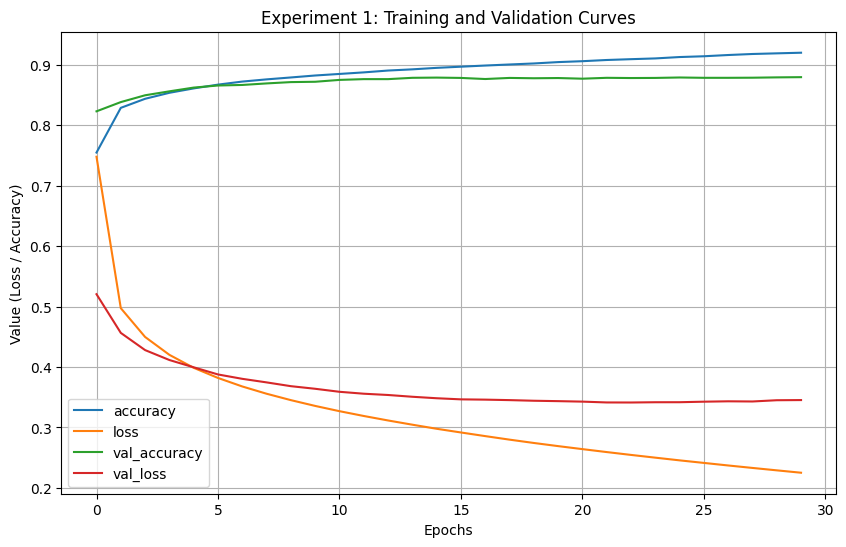

In [ ]:
import pandas as pd

# 1. Final Evaluation on testing data
print("Evaluating the model on the test dataset...")
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Final Test Accuracy: {test_acc * 100:.2f}%")
print(f"Final Test Loss: {test_loss:.4f}")

# 2. Visualize the Training and Validation Curves
pd.DataFrame(history.history).plot(figsize=(10, 6))
plt.grid(True)
plt.title("Experiment 1: Training and Validation Curves")
plt.xlabel("Epochs")
plt.ylabel("Value (Loss / Accuracy)")
plt.show()

In [ ]:


print("--- Starting Experiment 2 ---")
# 1. Build the second model with modifications (Adam Optimizer + Dropout)
model_2 = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dropout(0.3),  # Adding Dropout to prevent overfitting
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dropout(0.3),  # Adding Dropout to prevent overfitting
    keras.layers.Dense(10, activation="softmax")
])

# 2. Compile using 'adam' optimizer instead of 'sgd'
model_2.compile(loss="sparse_categorical_crossentropy",
                optimizer="adam",
                metrics=["accuracy"])

# Display the summary of the new model
model_2.summary()

--- Starting Experiment 2 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 3. Train Model 2
print("Training Model 2 (Adam + Dropout)...")
history_2 = model_2.fit(X_train, y_train, epochs=30, validation_data=(X_valid, y_valid))

Training Model 2 (Adam + Dropout)...
Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.7876 - loss: 0.5885 - val_accuracy: 0.8582 - val_loss: 0.3987
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8384 - loss: 0.4426 - val_accuracy: 0.8702 - val_loss: 0.3709
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8532 - loss: 0.4076 - val_accuracy: 0.8726 - val_loss: 0.3452
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8620 - loss: 0.3808 - val_accuracy: 0.8788 - val_loss: 0.3376
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8660 - loss: 0.3658 - val_accuracy: 0.8804 - val_loss: 0.3280
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8697 - loss: 0.3518 - val_accuracy: 0.8848 - val_loss: 0.3152
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8766 - loss: 0.3381 - val_accuracy: 0.8868 - val_loss: 0.3199
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 


Evaluating Model 2 on the test dataset...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1125 - loss: 2.4464
Model 2 Final Test Accuracy: 11.25%
Model 2 Final Test Loss: 2.4464


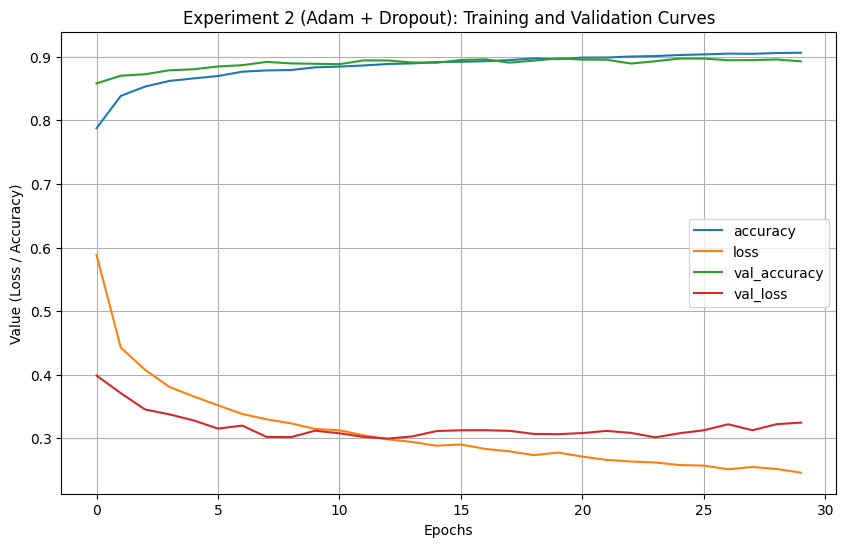


--- Final Results Comparison ---
Experiment 1 (SGD): Accuracy = 87.19%, Loss = 0.3618
Experiment 2 (Adam + Dropout): Accuracy = 11.25%, Loss = 2.4464


In [ ]:

import matplotlib.pyplot as plt

# 4. Evaluate Model 2 on the testing dataset
print("\nEvaluating Model 2 on the test dataset...")
test_loss_2, test_acc_2 = model_2.evaluate(X_test, y_test)
print(f"Model 2 Final Test Accuracy: {test_acc_2 * 100:.2f}%")
print(f"Model 2 Final Test Loss: {test_loss_2:.4f}")

# 5. Visualize Model 2 Curves
pd.DataFrame(history_2.history).plot(figsize=(10, 6))
plt.grid(True)
plt.title("Experiment 2 (Adam + Dropout): Training and Validation Curves")
plt.xlabel("Epochs")
plt.ylabel("Value (Loss / Accuracy)")
plt.show()

# 6. Final Comparison
print("\n==================================")
print("--- Final Results Comparison ---")
# Comparing with the first experiment
print(f"Experiment 1 (SGD): Accuracy = {test_acc*100:.2f}%, Loss = {test_loss:.4f}")
print(f"Experiment 2 (Adam + Dropout): Accuracy = {test_acc_2*100:.2f}%, Loss = {test_loss_2:.4f}")
print("==================================")